In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy
import os

In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]


In [3]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')

In [7]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'North North Island', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}


In [8]:
colors = ['blue','red','green','purple']
names = [winter_names, spring_names, summer_names, autumn_names]

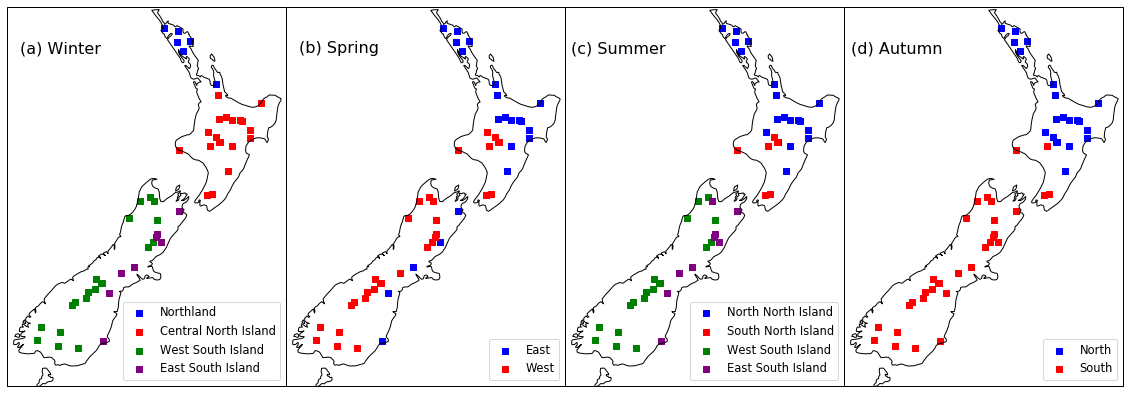

In [9]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
catchments_df_ae.index = catchments_df_ae.SITE.astype('int64')
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()

alpha = ['a','b','c','d']
for i,season in enumerate([winter,spring,summer,autumn]):
    
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.19, .89, "(" + alpha[i] + ") " + seasons_a[i], fontsize= 16, horizontalalignment="center", verticalalignment="center", transform=axs[i].transAxes)

    for j,cluster in enumerate(season):
        sites = season[cluster]
    
        #cluster_catch = catchments_df_ae.loc[[val for val in sites if val != 4901]]
        #cluster_catch.plot(ax=axs[i],color=colors[j],edgecolor='black',linewidth=0.2,alpha=0.3)
        
        for k,site in enumerate(season[cluster]):
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
            
            axs[i].scatter(lon,lat,marker='s',s=47, color=colors[j], label=names[i][j+1] if k == 0 else '')
            
    axs[i].legend(loc='lower right', prop={'size': 11.5})
            
plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig('Figure4.png',dpi=300,bbox_inches='tight')
